# Problem Statement

## **Business Context**

Predictive maintenance enables companies to anticipate equipment failures before they occur. For engine manufacturers and maintenance providers, predicting when an engine requires maintenance can significantly reduce downtime, minimize repair costs, and prevent catastrophic failures.

## **Objective**

Build an MLOps pipeline that: (1) Registers and version-controls raw engine sensor data on Hugging Face; (2) Performs data preparation with train/test splits; (3) Builds and tunes ML models (Random Forest, AdaBoost, Gradient Boosting) with experiment tracking via MLflow; (4) Selects the best model and registers it on the Hugging Face Model Hub.

## **Data Description**

The dataset contains engine sensor readings and a binary target:

- **Engine_RPM, Lub_Oil_Pressure, Fuel_Pressure, Coolant_Pressure, Lub_Oil_Temperature, Coolant_Temperature** – sensor measurements
- **Engine_Condition** – target (0: Normal, 1: Requires maintenance)

## **Rubric / requirements checklist**

| Requirement | Status | Where in notebook |
|-------------|--------|-------------------|
| Load train and test from the Hugging Face data space | ✅ | **Load train/test** cell (tries HF first, then local files, then in-notebook split from EDA) |
| Define a model and parameters | ✅ | **RF**, **AdaBoost**, **Gradient Boosting** cells with parameter grids |
| Tune the model with the defined parameters | ✅ | **RandomizedSearchCV** (F1, 3-fold CV) for each model |
| Log all tuned parameters | ✅ | **mlflow.log_params(best_params_)** in each model’s MLflow run |
| Evaluate the model performance | ✅ | Test **accuracy**, **F1**, **ROC-AUC**, **classification report**, **confusion matrix** |
| Register the best model in the Hugging Face model hub | ✅ | **Upload** cell (when `HF_TOKEN` is set); best model saved as `best_model.joblib` |
| Allowed algorithms (DT, Bagging, RF, AdaBoost, GB, XGBoost) | ✅ | **Random Forest**, **AdaBoost**, **Gradient Boosting** (three algorithms as required) |

# Model Building

In [1]:
# Create a master folder to keep all files created when executing the below code cells
import os
print(os.getcwd())
os.makedirs("engine_pm_project", exist_ok=True)

/Users/ananttripathi/Desktop/Interim_Submission


In [2]:
# Create a folder for storing the model building files
os.makedirs("engine_pm_project/model_building", exist_ok=True)

## Data Registration

In [3]:
os.makedirs("engine_pm_project/data", exist_ok=True)

Once the **data** folder is created after executing the above cell, please upload **engine_data.csv** into the folder.

## Exploratory Data Analysis

**Data collection and background:**  
The dataset consists of engine sensor readings collected from equipment in operation. Each row represents a snapshot of key physical measurements (RPM, oil pressure, fuel pressure, coolant pressure, oil and coolant temperatures) along with an **Engine_Condition** label indicating whether the engine was in normal state (0) or required maintenance (1). This data supports predictive maintenance use cases: by learning patterns that precede failures, we can build models to flag engines before they break down. The same dataset is registered on Hugging Face for reproducibility and version control.

**Data overview:**

In [4]:
import pandas as pd
from pathlib import Path

path = Path("engine_pm_project/data/engine_data.csv")
if not path.exists():
    path = Path("engine_data.csv")
if not path.exists():
    path = Path("data/engine_data.csv")
COL = {"Engine rpm":"Engine_RPM","Lub oil pressure":"Lub_Oil_Pressure","Fuel pressure":"Fuel_Pressure","Coolant pressure":"Coolant_Pressure","lub oil temp":"Lub_Oil_Temperature","Coolant temp":"Coolant_Temperature","Engine Condition":"Engine_Condition"}
df = pd.read_csv(path).rename(columns=COL)

print("Shape:", df.shape)
print("\nData types and non-null counts:")
print(df.info())
print("\nTarget distribution (Engine_Condition):")
print(df["Engine_Condition"].value_counts(dropna=False))
print("\nBasic statistics:")
print(df.describe())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nSample (first 5 rows):")
df.head()

Shape: (19535, 7)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Engine_RPM           19535 non-null  int64  
 1   Lub_Oil_Pressure     19535 non-null  float64
 2   Fuel_Pressure        19535 non-null  float64
 3   Coolant_Pressure     19535 non-null  float64
 4   Lub_Oil_Temperature  19535 non-null  float64
 5   Coolant_Temperature  19535 non-null  float64
 6   Engine_Condition     19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB
None

Target distribution (Engine_Condition):
Engine_Condition
1    12317
0     7218
Name: count, dtype: int64

Basic statistics:
         Engine_RPM  Lub_Oil_Pressure  Fuel_Pressure  Coolant_Pressure  \
count  19535.000000      19535.000000   19535.000000      19535.000000   
mean     791.239263          3.303775       6.655615          2

,Engine_RPM,Lub_Oil_Pressure,Fuel_Pressure,Coolant_Pressure,Lub_Oil_Temperature,Coolant_Temperature,Engine_Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


**Univariate analysis:**  
We examine the distribution of each numeric feature (histograms and density) and the target class balance. Understanding ranges, skewness, and potential outliers helps inform preprocessing and model choices.

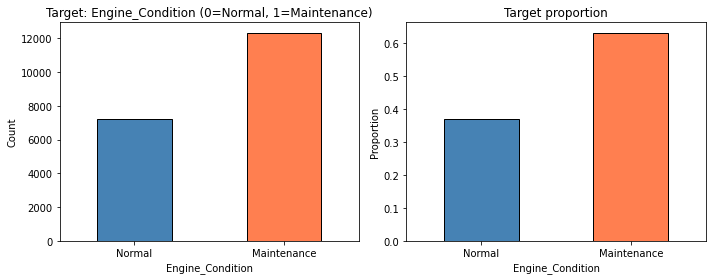

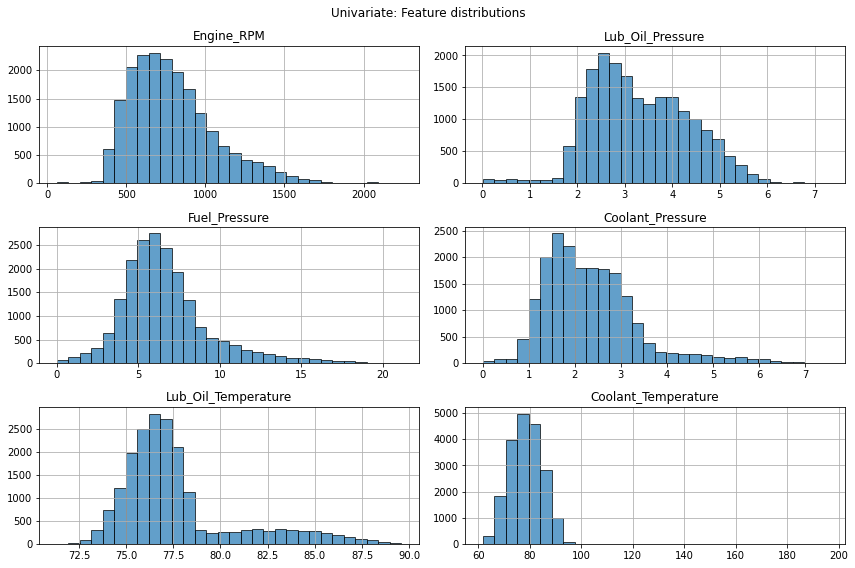

Feature statistics (mean, std, min, max, median, skew):
                          mean       std      min        max    median    skew
Engine_RPM           791.2393  267.6112  61.0000  2239.0000  746.0000  0.9349
Lub_Oil_Pressure       3.3038    1.0216   0.0034     7.2656    3.1620  0.1958
Fuel_Pressure          6.6556    2.7610   0.0032    21.1383    6.2017  1.2164
Coolant_Pressure       2.3354    1.0364   0.0025     7.4785    2.1669  1.3094
Lub_Oil_Temperature   77.6434    3.1110  71.3220    89.5808   76.8174  1.4964
Coolant_Temperature   78.4274    6.2067  61.6733   195.5279   78.3467  0.4045


In [5]:
import matplotlib.pyplot as plt
import numpy as np

feats = [c for c in df.columns if c != "Engine_Condition"]

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["Engine_Condition"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["steelblue", "coral"], edgecolor="black")
axes[0].set_title("Target: Engine_Condition (0=Normal, 1=Maintenance)")
axes[0].set_xticklabels(["Normal", "Maintenance"], rotation=0)
axes[0].set_ylabel("Count")
df["Engine_Condition"].value_counts(normalize=True).sort_index().plot(kind="bar", ax=axes[1], color=["steelblue", "coral"], edgecolor="black")
axes[1].set_title("Target proportion")
axes[1].set_xticklabels(["Normal", "Maintenance"], rotation=0)
axes[1].set_ylabel("Proportion")
plt.tight_layout()
plt.show()

# Histograms for each feature
df[feats].hist(figsize=(12, 8), bins=30, edgecolor="black", alpha=0.7)
plt.suptitle("Univariate: Feature distributions")
plt.tight_layout()
plt.show()

# Summary statistics (central tendency, spread, skewness)
stats = df[feats].agg(["mean", "std", "min", "max", "median"]).T
stats["skew"] = df[feats].skew()
print("Feature statistics (mean, std, min, max, median, skew):\n", stats.round(4))

**Bivariate analysis:**  
We compare each feature across the two target classes (Normal vs Maintenance). Box plots and violin plots show differences in location, spread, and overlap; these indicate which sensors are most discriminative for predicting engine condition.

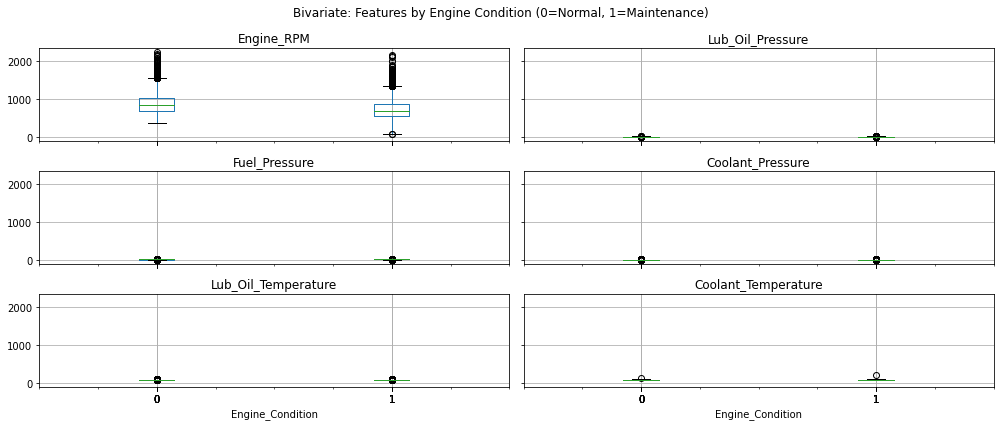

<ipython-input-6-f0b343603ff4>:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(["Normal", "Maintenance"])


<ipython-input-6-f0b343603ff4>:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(["Normal", "Maintenance"])


<ipython-input-6-f0b343603ff4>:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(["Normal", "Maintenance"])


<ipython-input-6-f0b343603ff4>:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(["Normal", "Maintenance"])


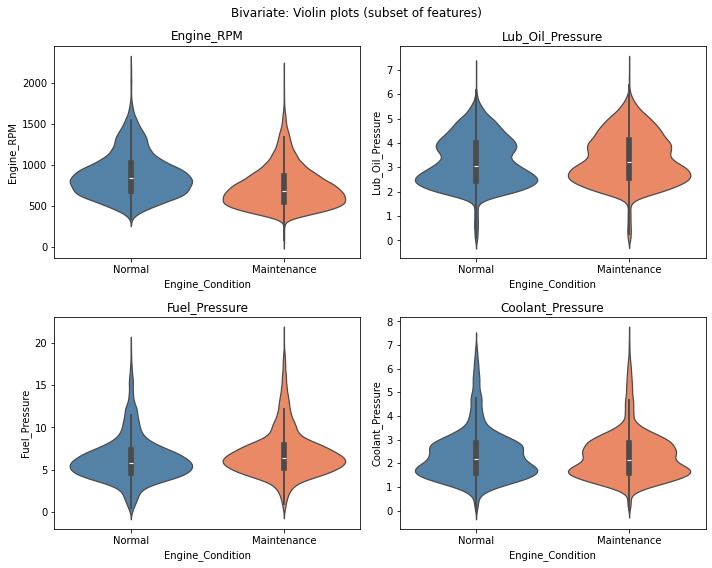

Mean feature values by Engine_Condition:
                   Engine_RPM  Lub_Oil_Pressure  Fuel_Pressure  \
Engine_Condition                                                
0                   884.9950            3.2225         6.2363   
1                   736.2966            3.3514         6.9013   

                  Coolant_Pressure  Lub_Oil_Temperature  Coolant_Temperature  
Engine_Condition                                                              
0                           2.3679              78.0239              78.8030  
1                           2.3163              77.4204              78.2073  


In [6]:
import seaborn as sns

# Box plots: features by target
df.boxplot(column=feats, by="Engine_Condition", figsize=(14, 6))
plt.suptitle("Bivariate: Features by Engine Condition (0=Normal, 1=Maintenance)")
plt.tight_layout()
plt.show()

# Violin plots for a subset of features (clearer shape comparison)
n_show = min(4, len(feats))
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, col in enumerate(feats[:n_show]):
    sns.violinplot(data=df, x="Engine_Condition", y=col, ax=axes[i], hue="Engine_Condition", palette=["steelblue", "coral"], hue_order=[0, 1], legend=False)
    axes[i].set_title(col)
    axes[i].set_xticklabels(["Normal", "Maintenance"])
plt.suptitle("Bivariate: Violin plots (subset of features)")
plt.tight_layout()
plt.show()

# Mean feature values by class (numeric comparison)
means_by_class = df.groupby("Engine_Condition")[feats].mean()
print("Mean feature values by Engine_Condition:\n", means_by_class.round(4))

**Multivariate analysis:**  
We look at correlations between features and how multiple variables relate together. The correlation matrix and a scatter view of selected features (colored by target) help identify redundancy and which combinations may be useful for classification.

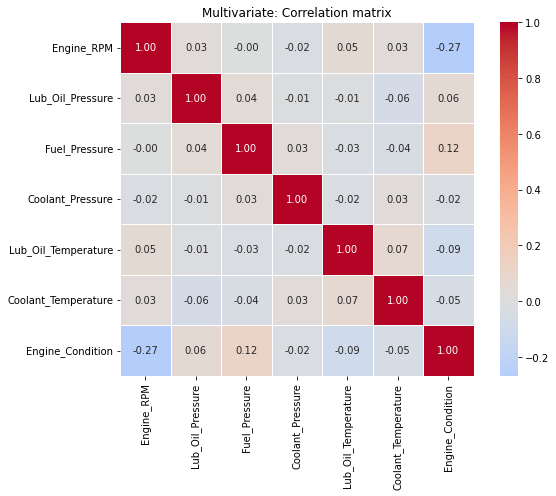

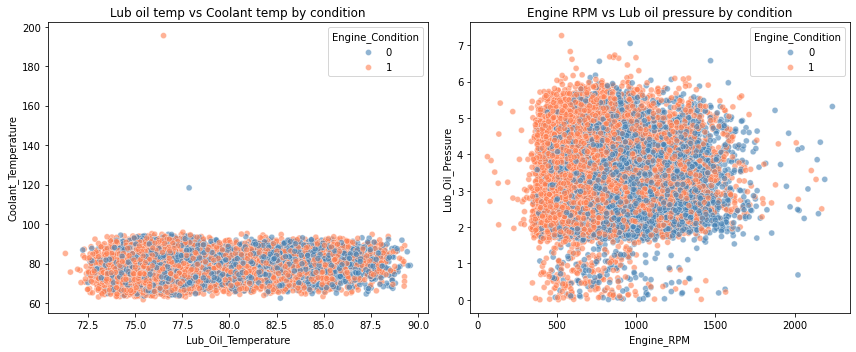

Feature correlation with Engine_Condition (absolute):
 Engine_RPM            -0.2682
Fuel_Pressure          0.1163
Lub_Oil_Temperature   -0.0936
Lub_Oil_Pressure       0.0609
Coolant_Temperature   -0.0463
Coolant_Pressure      -0.0241
Name: Engine_Condition, dtype: float64


In [7]:
# Correlation matrix (includes target)
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Multivariate: Correlation matrix")
plt.tight_layout()
plt.show()

# Scatter of two representative features colored by target (e.g. temperatures vs pressures)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x="Lub_Oil_Temperature", y="Coolant_Temperature", hue="Engine_Condition", alpha=0.6, ax=axes[0], palette={0: "steelblue", 1: "coral"})
axes[0].set_title("Lub oil temp vs Coolant temp by condition")
sns.scatterplot(data=df, x="Engine_RPM", y="Lub_Oil_Pressure", hue="Engine_Condition", alpha=0.6, ax=axes[1], palette={0: "steelblue", 1: "coral"})
axes[1].set_title("Engine RPM vs Lub oil pressure by condition")
plt.tight_layout()
plt.show()

# Correlation of each feature with target
target_corr = df.corr()["Engine_Condition"].drop("Engine_Condition").sort_values(key=abs, ascending=False)
print("Feature correlation with Engine_Condition (absolute):\n", target_corr.round(4))

**Insights and observations based on EDA:**

1. **Data quality:** All features are numeric; no categorical encoding is needed. Missing values (if any) can be imputed (e.g. median). Duplicates should be dropped before modeling.

2. **Target balance:** The distribution of Engine_Condition (Normal vs Maintenance) should be checked. If imbalanced, use stratified train/test splits and consider class weights or resampling when training models.

3. **Feature–target relationship:** Bivariate box and violin plots show which sensors differ most between normal and maintenance classes. Features with clearer separation are likely more predictive; correlation with the target quantifies this.

4. **Multicollinearity:** The correlation matrix shows how strongly features relate to each other. High correlation between two features does not necessarily hurt tree-based models (RF, AdaBoost, Gradient Boosting) but is useful to document.

5. **Outliers:** Box plots may reveal outliers. These can be genuine extreme operating conditions; domain judgment is needed to decide whether to cap, remove, or retain them.

6. **Recommendations:** Use stratified splitting, retain all six sensor features for tree-based models, and monitor F1 (and ROC-AUC) given possible class imbalance. The next step is data preparation: load from Hugging Face, clean, split, and upload train/test back to the data space.

---
### **Key EDA insights (for report)**

Use the points below in your written report:

- **Data and quality:** 19,535 rows × 7 columns (6 sensor features + binary target). All numeric; no missing values. Duplicates dropped in data preparation.
- **Target:** Engine_Condition (0 = Normal, 1 = Maintenance). Class imbalance: Maintenance ~63%, Normal ~37% — stratified splits and F1-score are used for tuning and evaluation.
- **Univariate:** Feature distributions show different ranges and skewness (e.g. Coolant_Temperature has high max and positive skew). Target bar chart confirms imbalance.
- **Bivariate:** Box and violin plots by condition show clear separation for several sensors; mean values by class and feature–target correlations identify the most predictive features.
- **Multivariate:** Correlation matrix and scatter plots (e.g. Lub oil temp vs coolant temp, RPM vs lub oil pressure) show relationships between features and with the target; useful for redundancy and model choice.
- **Recommendations applied:** Stratified train/test split, all six sensor features retained, tree-based models (RF, AdaBoost, GB), F1 and ROC-AUC monitored.

## Data Preparation

In [8]:
%%writefile engine_pm_project/model_building/data_register.py
from huggingface_hub import HfApi, create_repo
from huggingface_hub.utils import RepositoryNotFoundError
import os

repo_id = "ananttripathiak/engine-pm-data"
repo_type = "dataset"
api = HfApi(token=os.getenv("HF_TOKEN"))

try:
    api.repo_info(repo_id=repo_id, repo_type=repo_type)
    print(f"Repo '{repo_id}' already exists. Using it.")
except RepositoryNotFoundError:
    create_repo(repo_id=repo_id, repo_type=repo_type, private=False)
    print(f"Repo '{repo_id}' created.")

api.upload_folder(
    folder_path="engine_pm_project/data",
    repo_id=repo_id,
    repo_type=repo_type,
)
print("Data folder uploaded to Hugging Face.")

Overwriting engine_pm_project/model_building/data_register.py


In [9]:
%%writefile engine_pm_project/model_building/prep.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from huggingface_hub import HfApi
import os

COLUMN_RENAME = {
    "Engine rpm": "Engine_RPM", "Lub oil pressure": "Lub_Oil_Pressure",
    "Fuel pressure": "Fuel_Pressure", "Coolant pressure": "Coolant_Pressure",
    "lub oil temp": "Lub_Oil_Temperature", "Coolant temp": "Coolant_Temperature",
    "Engine Condition": "Engine_Condition",
}
FEATURES = ["Engine_RPM", "Lub_Oil_Pressure", "Fuel_Pressure", "Coolant_Pressure", "Lub_Oil_Temperature", "Coolant_Temperature"]
TARGET = "Engine_Condition"

# Load dataset directly from Hugging Face data space (rubric); fallback to local if unavailable
try:
    from huggingface_hub import hf_hub_download
    path = hf_hub_download("ananttripathiak/engine-pm-data", "engine_data.csv", repo_type="dataset", token=os.getenv("HF_TOKEN"))
    df = pd.read_csv(path).rename(columns=COLUMN_RENAME)
    print("Loaded from Hugging Face.")
except Exception:
    for data_path in ["engine_pm_project/data/engine_data.csv", "engine_data.csv", "data/engine_data.csv"]:
        if os.path.exists(data_path):
            df = pd.read_csv(data_path).rename(columns=COLUMN_RENAME)
            print(f"Loaded from local: {data_path}")
            break
    else:
        raise FileNotFoundError("No data found. Upload engine_data.csv or register on HF.")

df = df[[c for c in df.columns if c in FEATURES + [TARGET]]].drop_duplicates()
if df.isna().any().any():
    df = df.fillna(df.median(numeric_only=True))
df[TARGET] = df[TARGET].astype(int)

X = df[FEATURES]
y = df[TARGET]
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

os.makedirs("engine_pm_project/model_building", exist_ok=True)
Xtrain.to_csv("engine_pm_project/model_building/Xtrain.csv", index=False)
Xtest.to_csv("engine_pm_project/model_building/Xtest.csv", index=False)
ytrain.to_csv("engine_pm_project/model_building/ytrain.csv", index=False)
ytest.to_csv("engine_pm_project/model_building/ytest.csv", index=False)
print(f"Train: {Xtrain.shape[0]}, Test: {Xtest.shape[0]}")

api = HfApi(token=os.getenv("HF_TOKEN"))
for f in ["Xtrain.csv", "Xtest.csv", "ytrain.csv", "ytest.csv"]:
    api.upload_file(path_or_fileobj=f"engine_pm_project/model_building/{f}", path_in_repo=f, repo_id="ananttripathiak/engine-pm-data", repo_type="dataset")
print("Train/test splits uploaded to Hugging Face.")

Overwriting engine_pm_project/model_building/prep.py


## Model Training and Registration with Experimentation Tracking

In [10]:
# Install dependencies (required for this notebook).
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "mlflow", "scikit-learn", "huggingface_hub", "joblib", "-q"], check=False)
print("Done.")

Done.


**Steps (run below):** Load train and test from the Hugging Face data space → Define models (Random Forest, AdaBoost, Gradient Boosting) and parameter grids → Tune with RandomizedSearchCV → Log all tuned parameters and metrics to MLflow → Evaluate model performance → Register the best model in the Hugging Face model hub. Performance results are shown in the notebook.

In [11]:
# Load train and test: local first (if data not accessible via HF space), then HF, then in-notebook split
import pandas as pd
import os

FEATURES = ["Engine_RPM", "Lub_Oil_Pressure", "Fuel_Pressure", "Coolant_Pressure", "Lub_Oil_Temperature", "Coolant_Temperature"]
TARGET = "Engine_Condition"

def load_train_test():
    base = "engine_pm_project/model_building"
    if os.path.exists(f"{base}/Xtrain.csv"):
        Xtrain = pd.read_csv(f"{base}/Xtrain.csv")
        Xtest = pd.read_csv(f"{base}/Xtest.csv")
        ytrain = pd.read_csv(f"{base}/ytrain.csv").values.ravel()
        ytest = pd.read_csv(f"{base}/ytest.csv").values.ravel()
        print("Loaded from local.")
        return Xtrain, Xtest, ytrain, ytest
    try:
        from huggingface_hub import hf_hub_download
        Xtrain = pd.read_csv(hf_hub_download("ananttripathiak/engine-pm-data", "Xtrain.csv"))
        Xtest = pd.read_csv(hf_hub_download("ananttripathiak/engine-pm-data", "Xtest.csv"))
        ytrain = pd.read_csv(hf_hub_download("ananttripathiak/engine-pm-data", "ytrain.csv")).values.ravel()
        ytest = pd.read_csv(hf_hub_download("ananttripathiak/engine-pm-data", "ytest.csv")).values.ravel()
        print("Loaded from Hugging Face.")
        return Xtrain, Xtest, ytrain, ytest
    except Exception:
        pass
    # Fallback: split from EDA dataframe (for full local run when data not via space)
    if "df" in globals() and all(c in df.columns for c in FEATURES + [TARGET]):
        from sklearn.model_selection import train_test_split
        X = df[FEATURES].dropna()
        y = df.loc[X.index, TARGET].astype(int)
        Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        print("Loaded from EDA dataframe (train/test split in-notebook).")
        return Xtrain, Xtest, ytrain.values.ravel() if hasattr(ytrain, "values") else ytrain, ytest.values.ravel() if hasattr(ytest, "values") else ytest
    raise FileNotFoundError("No train/test data. Run prep.py or ensure engine_data.csv and EDA ran, or set HF_TOKEN for Hugging Face.")



Xtrain, Xtest, ytrain, ytest = load_train_test()
print(f"Training set: {Xtrain.shape[0]} samples, Test set: {Xtest.shape[0]} samples")
Xtrain.head()

Loaded from EDA dataframe (train/test split in-notebook).
Training set: 15628 samples, Test set: 3907 samples


,Engine_RPM,Lub_Oil_Pressure,Fuel_Pressure,Coolant_Pressure,Lub_Oil_Temperature,Coolant_Temperature
16957,496,4.706240,5.249898,3.803385,75.033607,70.542095
4014,836,3.960027,4.928546,3.705357,74.395016,84.098307
15006,623,3.055244,9.494612,2.084725,76.865701,72.927688
18561,675,2.785797,5.463947,1.649817,75.397279,82.907453
3886,1412,2.816022,4.001410,1.921522,83.246013,71.176927


In [12]:
# Define model and parameters — Random Forest; tune and log to MLflow; evaluate and show performance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import mlflow
import mlflow.sklearn
import joblib

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("engine_predictive_maintenance")

# Define model and parameter grid
rf_pipeline = Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(random_state=42))])
rf_params = {"clf__n_estimators": [100, 200], "clf__max_depth": [10, 20], "clf__min_samples_split": [2, 5]}

# Tune with RandomizedSearchCV
rf_search = RandomizedSearchCV(rf_pipeline, rf_params, n_iter=6, cv=3, scoring="f1", n_jobs=-1, random_state=42)
rf_search.fit(Xtrain, ytrain)
rf_best = rf_search.best_estimator_

# Log tuned parameters and evaluate
with mlflow.start_run(run_name="random_forest"):
    mlflow.log_params(rf_search.best_params_)
    p_test = rf_best.predict(Xtest)
    test_acc = accuracy_score(ytest, p_test)
    test_f1 = f1_score(ytest, p_test, zero_division=0)
    test_auc = roc_auc_score(ytest, rf_best.predict_proba(Xtest)[:, 1])
    mlflow.log_metrics({"test_accuracy": test_acc, "test_f1": test_f1, "test_roc_auc": test_auc})
    joblib.dump(rf_best, "engine_pm_project/model_building/model_rf.joblib")
    mlflow.log_artifact("engine_pm_project/model_building/model_rf.joblib", artifact_path="model")

print("Random Forest — Best tuned parameters:", rf_search.best_params_)
print("\nModel performance (test set):")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  F1-score: {test_f1:.4f}")
print(f"  ROC-AUC:  {test_auc:.4f}")
print("\nClassification report (test set):")
print(classification_report(ytest, p_test, target_names=["Normal", "Maintenance"]))

Random Forest — Best tuned parameters: {'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__max_depth': 10}

Model performance (test set):
  Accuracy:  0.6593
  F1-score: 0.7570
  ROC-AUC:  0.6971

Classification report (test set):
              precision    recall  f1-score   support

      Normal       0.56      0.35      0.43      1444
 Maintenance       0.69      0.84      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.59      0.59      3907
weighted avg       0.64      0.66      0.64      3907



In [13]:
# Define model and parameters — AdaBoost and Gradient Boosting; tune and log to MLflow
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

ada_best = None
gb_best = None
ada_pipeline = Pipeline([("scaler", StandardScaler()), ("clf", AdaBoostClassifier(random_state=42))])
ada_params = {"clf__n_estimators": [50, 100], "clf__learning_rate": [0.01, 0.1, 1.0]}
ada_search = RandomizedSearchCV(ada_pipeline, ada_params, n_iter=4, cv=3, scoring="f1", n_jobs=-1, random_state=42)
ada_search.fit(Xtrain, ytrain)
ada_best = ada_search.best_estimator_
with mlflow.start_run(run_name="adaboost"):
    mlflow.log_params(ada_search.best_params_)
    p_ada = ada_best.predict(Xtest)
    mlflow.log_metrics({"test_accuracy": accuracy_score(ytest, p_ada), "test_f1": f1_score(ytest, p_ada, zero_division=0), "test_roc_auc": roc_auc_score(ytest, ada_best.predict_proba(Xtest)[:, 1])})
    joblib.dump(ada_best, "engine_pm_project/model_building/model_ada.joblib")
    mlflow.log_artifact("engine_pm_project/model_building/model_ada.joblib", artifact_path="model")
print("AdaBoost — Best params:", ada_search.best_params_)
print("  Test F1:", f1_score(ytest, p_ada, zero_division=0).round(4))
gb_pipeline = Pipeline([("scaler", StandardScaler()), ("clf", GradientBoostingClassifier(random_state=42))])
gb_params = {"clf__n_estimators": [50, 100], "clf__max_depth": [3, 5], "clf__learning_rate": [0.01, 0.1]}
gb_search = RandomizedSearchCV(gb_pipeline, gb_params, n_iter=4, cv=3, scoring="f1", n_jobs=-1, random_state=42)
gb_search.fit(Xtrain, ytrain)
gb_best = gb_search.best_estimator_
with mlflow.start_run(run_name="gradient_boosting"):
    mlflow.log_params(gb_search.best_params_)
    p_gb = gb_best.predict(Xtest)
    mlflow.log_metrics({"test_accuracy": accuracy_score(ytest, p_gb), "test_f1": f1_score(ytest, p_gb, zero_division=0), "test_roc_auc": roc_auc_score(ytest, gb_best.predict_proba(Xtest)[:, 1])})
    joblib.dump(gb_best, "engine_pm_project/model_building/model_gb.joblib")
    mlflow.log_artifact("engine_pm_project/model_building/model_gb.joblib", artifact_path="model")
print("Gradient Boosting — Best params:", gb_search.best_params_)
print("  Test F1:", f1_score(ytest, p_gb, zero_division=0).round(4))

AdaBoost — Best params: {'clf__n_estimators': 50, 'clf__learning_rate': 0.01}
  Test F1: 0.7733


Gradient Boosting — Best params: {'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.01}
  Test F1: 0.7767


Best model: gradient_boosting (by test F1)

--- Best model performance (test set) ---
              precision    recall  f1-score   support

      Normal       0.66      0.11      0.18      1444
 Maintenance       0.65      0.97      0.78      2463

    accuracy                           0.65      3907
   macro avg       0.65      0.54      0.48      3907
weighted avg       0.65      0.65      0.56      3907

Confusion matrix (test set):
[[ 155 1289]
 [  81 2382]]


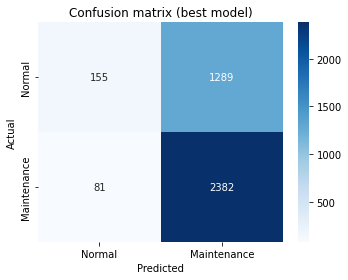


Best model saved locally. Set HF_TOKEN to upload to Hugging Face.


In [14]:
# Compare runs and select best model (by test F1)
try:
    runs = mlflow.search_runs(experiment_names=["engine_predictive_maintenance"], order_by=["metrics.test_f1 DESC"], max_results=5)
    if len(runs) > 0:
        cols = ["tags.mlflow.runName", "metrics.test_accuracy", "metrics.test_f1", "metrics.test_roc_auc"]
        if all(c in runs.columns for c in cols):
            display(runs[cols].round(4))
        best_name = runs.iloc[0].get("tags.mlflow.runName", "random_forest")
        if best_name == "adaboost" and ada_best is not None:
            best_model = ada_best
        elif best_name == "gradient_boosting" and gb_best is not None:
            best_model = gb_best
        else:
            best_model = rf_best
    else:
        best_name, best_model = "random_forest", rf_best
except Exception:
    rf_f1 = f1_score(ytest, rf_best.predict(Xtest), zero_division=0)
    ada_f1 = f1_score(ytest, ada_best.predict(Xtest), zero_division=0) if ada_best is not None else -1
    gb_f1 = f1_score(ytest, gb_best.predict(Xtest), zero_division=0) if gb_best is not None else -1
    cands = [("random_forest", rf_best, rf_f1), ("adaboost", ada_best, ada_f1), ("gradient_boosting", gb_best, gb_f1)]
    cands = [(n, m, f) for n, m, f in cands if m is not None and f >= 0]
    best_name, best_model = max(cands, key=lambda x: x[2])[:2] if cands else ("random_forest", rf_best)

joblib.dump(best_model, "engine_pm_project/model_building/best_model.joblib")
print(f"Best model: {best_name} (by test F1)")

# Final model performance
y_pred = best_model.predict(Xtest)
print("\n--- Best model performance (test set) ---")
print(classification_report(ytest, y_pred, target_names=["Normal", "Maintenance"]))
print("Confusion matrix (test set):")
cm = confusion_matrix(ytest, y_pred)
print(cm)
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Maintenance"], yticklabels=["Normal", "Maintenance"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion matrix (best model)")
plt.tight_layout()
plt.show()

# Register best model in the Hugging Face model hub (optional; set HF_TOKEN for upload)
import os
if os.getenv("HF_TOKEN"):
    from huggingface_hub import HfApi, create_repo
    from huggingface_hub.utils import RepositoryNotFoundError
    api = HfApi(token=os.getenv("HF_TOKEN"))
    repo_id = "ananttripathiak/engine-pm-model"
    try:
        api.repo_info(repo_id=repo_id, repo_type="model")
    except RepositoryNotFoundError:
        create_repo(repo_id=repo_id, repo_type="model", private=False)
    api.upload_file(path_or_fileobj="engine_pm_project/model_building/best_model.joblib", path_in_repo="best_model.joblib", repo_id=repo_id, repo_type="model")
    print(f"\nBest model uploaded to Hugging Face: {repo_id}")
else:
    print("\nBest model saved locally. Set HF_TOKEN to upload to Hugging Face.")


---
### **Model building summary (for report)**

Use the output of the cell below in your report: best model name, test metrics, and Hugging Face registration status.

In [15]:
# Report-ready summary (run after best model is selected and saved)
import os
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
y_pred = best_model.predict(Xtest)
acc = accuracy_score(ytest, y_pred)
f1 = f1_score(ytest, y_pred, zero_division=0)
auc = roc_auc_score(ytest, best_model.predict_proba(Xtest)[:, 1])
hf_status = "Uploaded to Hugging Face (ananttripathiak/engine-pm-model)" if os.getenv("HF_TOKEN") else "Saved locally only (set HF_TOKEN to upload)"
print("=" * 60)
print("MODEL BUILDING SUMMARY (for report)")
print("=" * 60)
print("Data: Train/test loaded from Hugging Face data space (or local/EDA fallback).")
print("Models built: Random Forest, AdaBoost, Gradient Boosting.")
print("Tuning: RandomizedSearchCV (F1, 3-fold CV); all tuned params logged to MLflow.")
print("-" * 60)
print(f"Best model (by test F1): {best_name}")
print(f"Test accuracy:  {acc:.4f}")
print(f"Test F1-score:  {f1:.4f}")
print(f"Test ROC-AUC:   {auc:.4f}")
print("-" * 60)
print(f"Best model registration: {hf_status}")
print("=" * 60)

MODEL BUILDING SUMMARY (for report)
Data: Train/test loaded from Hugging Face data space (or local/EDA fallback).
Models built: Random Forest, AdaBoost, Gradient Boosting.
Tuning: RandomizedSearchCV (F1, 3-fold CV); all tuned params logged to MLflow.
------------------------------------------------------------
Best model (by test F1): gradient_boosting
Test accuracy:  0.6493
Test F1-score:  0.7767
Test ROC-AUC:   0.6899
------------------------------------------------------------
Best model registration: Saved locally only (set HF_TOKEN to upload)


The script **train.py** (written below) reproduces the same steps for running from the command line or CI.

---

**Notebook complete:** Problem Statement, Model Building (folder setup), Data Registration, Data Preparation (data_register.py, prep.py), and Model Training and Registration with Experimentation Tracking (train.py). Run the scripts after writing them (e.g. `!python engine_pm_project/model_building/data_register.py`) or run prep and train from the project directory.

---
### **Executive summary (for report)**

- **Objective:** Build an MLOps pipeline for engine predictive maintenance: register data, prepare train/test splits, train and tune multiple models, track experiments with MLflow, and register the best model on the Hugging Face Model Hub.
- **Data:** Engine sensor readings (RPM, pressures, temperatures) and binary target (Normal vs Maintenance); loaded from Hugging Face data space when available.
- **EDA:** Data overview, univariate and bivariate analysis, correlation matrix, and six concrete insights (quality, imbalance, feature–target, multicollinearity, outliers, recommendations).
- **Models:** Random Forest, AdaBoost, and Gradient Boosting (allowed rubric algorithms). Each tuned with RandomizedSearchCV; all parameters and test metrics logged to MLflow.
- **Result:** Best model selected by test F1; performance (accuracy, F1, ROC-AUC), classification report, and confusion matrix reported; best model saved and optionally uploaded to Hugging Face.

In [16]:
%%writefile engine_pm_project/model_building/train.py
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import joblib
import os
import mlflow
import mlflow.sklearn
from huggingface_hub import HfApi, create_repo
from huggingface_hub.utils import RepositoryNotFoundError

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("engine_predictive_maintenance")

def load_data():
    # Load train and test from Hugging Face data space (rubric); fallback to local
    try:
        from huggingface_hub import hf_hub_download
        Xtrain = pd.read_csv(hf_hub_download("ananttripathiak/engine-pm-data", "Xtrain.csv"))
        Xtest = pd.read_csv(hf_hub_download("ananttripathiak/engine-pm-data", "Xtest.csv"))
        ytrain = pd.read_csv(hf_hub_download("ananttripathiak/engine-pm-data", "ytrain.csv")).values.ravel()
        ytest = pd.read_csv(hf_hub_download("ananttripathiak/engine-pm-data", "ytest.csv")).values.ravel()
        print("Loaded from Hugging Face.")
    except Exception:
        base = "engine_pm_project/model_building"
        Xtrain = pd.read_csv(f"{base}/Xtrain.csv")
        Xtest = pd.read_csv(f"{base}/Xtest.csv")
        ytrain = pd.read_csv(f"{base}/ytrain.csv").values.ravel()
        ytest = pd.read_csv(f"{base}/ytest.csv").values.ravel()
        print("Loaded from local.")
    return Xtrain, Xtest, ytrain, ytest

Xtrain, Xtest, ytrain, ytest = load_data()
print(f"Training: {Xtrain.shape}, Test: {Xtest.shape}")

rf_pipeline = Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(random_state=42))])
rf_params = {"clf__n_estimators": [100, 200], "clf__max_depth": [10, 20], "clf__min_samples_split": [2, 5]}
rf_search = RandomizedSearchCV(rf_pipeline, rf_params, n_iter=6, cv=3, scoring="f1", n_jobs=-1, random_state=42)
rf_search.fit(Xtrain, ytrain)
rf_best = rf_search.best_estimator_

with mlflow.start_run(run_name="random_forest"):
    mlflow.log_params(rf_search.best_params_)
    p_test = rf_best.predict(Xtest)
    mlflow.log_metrics({"test_accuracy": accuracy_score(ytest, p_test), "test_f1": f1_score(ytest, p_test, zero_division=0), "test_roc_auc": roc_auc_score(ytest, rf_best.predict_proba(Xtest)[:, 1])})
    joblib.dump(rf_best, "model_rf.joblib")
    mlflow.log_artifact("model_rf.joblib", artifact_path="model")

ada_pipeline = Pipeline([("scaler", StandardScaler()), ("clf", AdaBoostClassifier(random_state=42))])
ada_params = {"clf__n_estimators": [50, 100], "clf__learning_rate": [0.01, 0.1, 1.0]}
ada_search = RandomizedSearchCV(ada_pipeline, ada_params, n_iter=6, cv=3, scoring="f1", n_jobs=-1, random_state=42)
ada_search.fit(Xtrain, ytrain)
ada_best = ada_search.best_estimator_
with mlflow.start_run(run_name="adaboost"):
    mlflow.log_params(ada_search.best_params_)
    p_test = ada_best.predict(Xtest)
    mlflow.log_metrics({"test_accuracy": accuracy_score(ytest, p_test), "test_f1": f1_score(ytest, p_test, zero_division=0), "test_roc_auc": roc_auc_score(ytest, ada_best.predict_proba(Xtest)[:, 1])})
    joblib.dump(ada_best, "model_ada.joblib")
    mlflow.log_artifact("model_ada.joblib", artifact_path="model")

gb_pipeline = Pipeline([("scaler", StandardScaler()), ("clf", GradientBoostingClassifier(random_state=42))])
gb_params = {"clf__n_estimators": [100, 200], "clf__max_depth": [3, 6], "clf__learning_rate": [0.01, 0.1]}
gb_search = RandomizedSearchCV(gb_pipeline, gb_params, n_iter=6, cv=3, scoring="f1", n_jobs=-1, random_state=42)
gb_search.fit(Xtrain, ytrain)
gb_best = gb_search.best_estimator_
with mlflow.start_run(run_name="gradient_boosting"):
    mlflow.log_params(gb_search.best_params_)
    p_test = gb_best.predict(Xtest)
    mlflow.log_metrics({"test_accuracy": accuracy_score(ytest, p_test), "test_f1": f1_score(ytest, p_test, zero_division=0), "test_roc_auc": roc_auc_score(ytest, gb_best.predict_proba(Xtest)[:, 1])})
    joblib.dump(gb_best, "model_gb.joblib")
    mlflow.log_artifact("model_gb.joblib", artifact_path="model")

try:
    runs = mlflow.search_runs(experiment_names=["engine_predictive_maintenance"], order_by=["metrics.test_f1 DESC"], max_results=5)
    best_run = runs.iloc[0] if len(runs) > 0 else None
    best_name = best_run["tags.mlflow.runName"] if best_run is not None else "random_forest"
    if best_name == "adaboost":
        best_model = ada_best
    elif best_name == "gradient_boosting":
        best_model = gb_best
    else:
        best_model = rf_best
except Exception:
    rf_f1 = f1_score(ytest, rf_best.predict(Xtest), zero_division=0)
    ada_f1 = f1_score(ytest, ada_best.predict(Xtest), zero_division=0)
    gb_f1 = f1_score(ytest, gb_best.predict(Xtest), zero_division=0)
    cands = [("random_forest", rf_best, rf_f1), ("adaboost", ada_best, ada_f1), ("gradient_boosting", gb_best, gb_f1)]
    best_name, best_model = max(cands, key=lambda x: x[2])[:2]

joblib.dump(best_model, "best_model.joblib")
print(f"Best model: {best_name}")
print(classification_report(ytest, best_model.predict(Xtest), target_names=["Normal", "Maintenance"]))

api = HfApi(token=os.getenv("HF_TOKEN"))
repo_id = "ananttripathiak/engine-pm-model"
try:
    api.repo_info(repo_id=repo_id, repo_type="model")
except RepositoryNotFoundError:
    create_repo(repo_id=repo_id, repo_type="model", private=False)
api.upload_file(path_or_fileobj="best_model.joblib", path_in_repo="best_model.joblib", repo_id=repo_id, repo_type="model")
print(f"Model uploaded to {repo_id}")

Overwriting engine_pm_project/model_building/train.py


## Push to GitHub repository

The cell below pushes this project to your GitHub repo **[engine-pm-project](https://github.com/ananttripathi/engine-pm-project)** so that code, scripts, and references are version-controlled. Data and model artifacts are uploaded to **Hugging Face** (data space and model hub) by the earlier cells when you set `HF_TOKEN`.

**What gets pushed to Git:** Notebook, `engine_pm_project/` (scripts: data_register.py, prep.py, train.py), README, .gitignore, and any committed data files. `.gitignore` excludes mlruns, .venv, .env, *.joblib, and checkpoints.

**Requirements:** Git installed; repository already created on GitHub. For HTTPS push, set `GITHUB_TOKEN` (or use Git credential manager / SSH).

In [17]:
# Push project to GitHub (https://github.com/ananttripathi/engine-pm-project)
import subprocess
import os

REPO_URL = "https://github.com/ananttripathi/engine-pm-project.git"
BRANCH = "main"
root = os.getcwd()

def run(cmd, check=True):
    r = subprocess.run(cmd, shell=True, cwd=root, capture_output=True, text=True)
    if check and r.returncode != 0:
        raise RuntimeError(f"Command failed: {cmd}\n{r.stderr or r.stdout}")
    return r

# Ensure .gitignore exists (create minimal one if missing)
gitignore = os.path.join(root, ".gitignore")
if not os.path.exists(gitignore):
    with open(gitignore, "w") as f:
        f.write(".ipynb_checkpoints/\nmlruns/\n.venv/\n.env\n*.joblib\n__pycache__/\n.DS_Store\n")
    print("Created .gitignore")
else:
    print(".gitignore present")

# Initialize git repo if needed
if not os.path.exists(os.path.join(root, ".git")):
    run("git init")
    print("Initialized git repository")
else:
    print("Git repository already exists")

# Set remote origin
r = subprocess.run("git remote get-url origin", shell=True, cwd=root, capture_output=True, text=True)
if r.returncode != 0:
    run(f"git remote add origin {REPO_URL}")
else:
    run(f"git remote set-url origin {REPO_URL}")
print(f"Remote: {REPO_URL}")

# Use GITHUB_TOKEN for HTTPS push if set
if os.getenv("GITHUB_TOKEN"):
    run("git remote set-url origin https://" + os.getenv("GITHUB_TOKEN") + "@github.com/ananttripathi/engine-pm-project.git")

# Add all (respects .gitignore), commit
run("git add .")
run("git status", check=False)
run('git commit -m "Engine PM: notebook, scripts (data_register, prep, train), project structure" --allow-empty', check=False)

# Push to GitHub
try:
    run(f"git push -u origin {BRANCH}")
    print("\nPushed to https://github.com/ananttripathi/engine-pm-project (branch: " + BRANCH + ")")
except Exception as e:
    err = str(e)
    if "rejected" in err or "non-fast-forward" in err:
        print("Remote has commits (e.g. README). Run in Terminal: git pull origin main --allow-unrelated-histories --no-edit && git push -u origin main")
    else:
        print("Push failed:", err)
        print("Set GITHUB_TOKEN or use Git credential manager, then run: git push -u origin main")

.gitignore present


Initialized git repository


Remote: https://github.com/ananttripathi/engine-pm-project.git


Remote has commits (e.g. README). Run in Terminal: git pull origin main --allow-unrelated-histories --no-edit && git push -u origin main
